Part 1 — Setup & Data Upload

Load required libraries, upload Housing Price.csv, clean column names, convert yes/no fields to numeric, normalize furnishingstatus, remove duplicates and invalid rows, and prepare the numeric feature list.


In [ ]:

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from google.colab import files, data_table
import io, re

uploaded = files.upload()
csv_name = list(uploaded.keys())[0]

raw_text = uploaded[csv_name].decode("utf-8", errors="ignore")
raw_text = raw_text.replace("&gt;", ">").replace("&lt;", "<").replace("&amp;", "&")
raw_text = raw_text.replace("\ufeff", "")
raw_text = re.sub(r"[^\S\r\n]+", lambda m: " " if "," not in m.group(0) else m.group(0), raw_text)

df = pd.read_csv(io.StringIO(raw_text), on_bad_lines="skip")
df.columns = [c.strip().lower() for c in df.columns]

binary_cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for c in binary_cols:
    if c in df.columns and df[c].dtype == object:
        df[c] = df[c].str.strip().str.lower().map({"yes":1,"no":0})

if "furnishingstatus" in df.columns and df["furnishingstatus"].dtype == object:
    df["furnishingstatus"] = df["furnishingstatus"].str.strip().str.lower()

df = df.drop_duplicates()
df = df[(df["price"] > 0) & (df["area"] > 0)]

numeric_cols = ["area","bedrooms","bathrooms","stories","parking"]
present_numeric = [c for c in numeric_cols if c in df.columns]

print("Loaded shape:", df.shape)
print(df.head(3))


Saving Housing Price.csv to Housing Price (1).csv
Loaded shape: (545, 13)
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   

  furnishingstatus  
0        furnished  
1        furnished  
2   semi-furnished  


Part 2 — Quick EDA Visuals

 Show price distribution, visualize the relationship between area and price, and plot a correlation heatmap for numeric features to understand feature–target relationships.


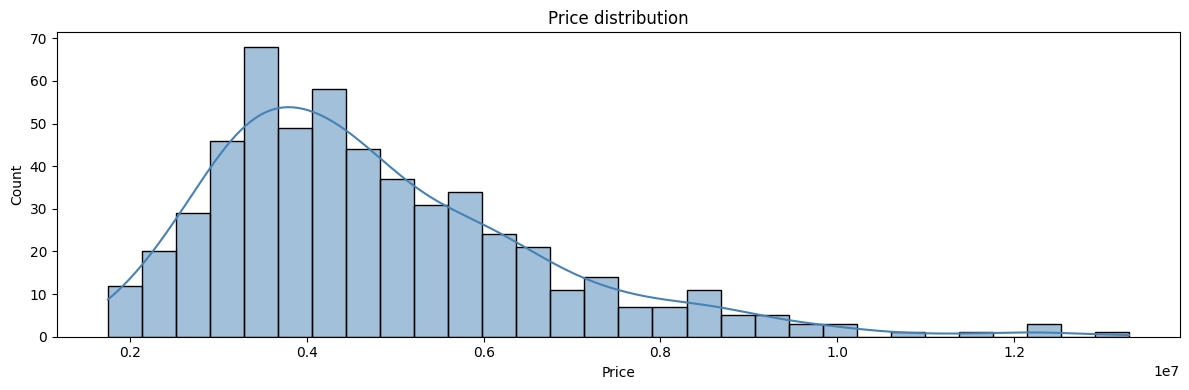

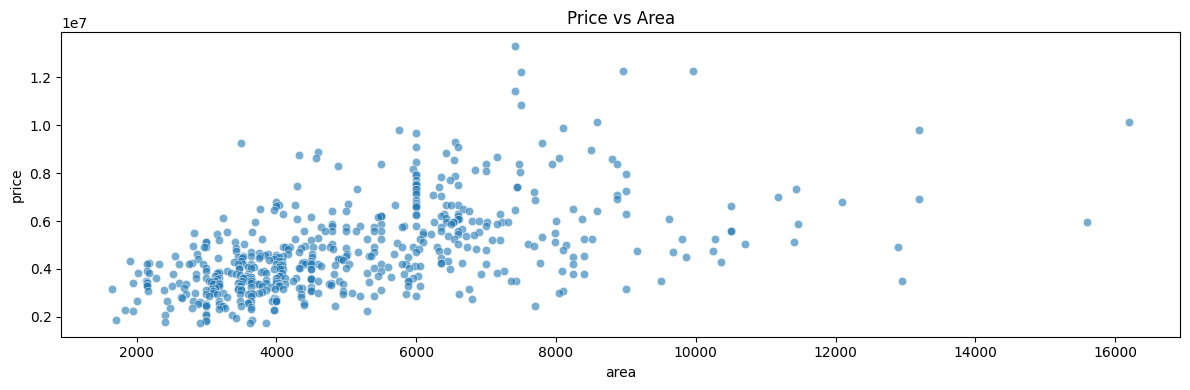

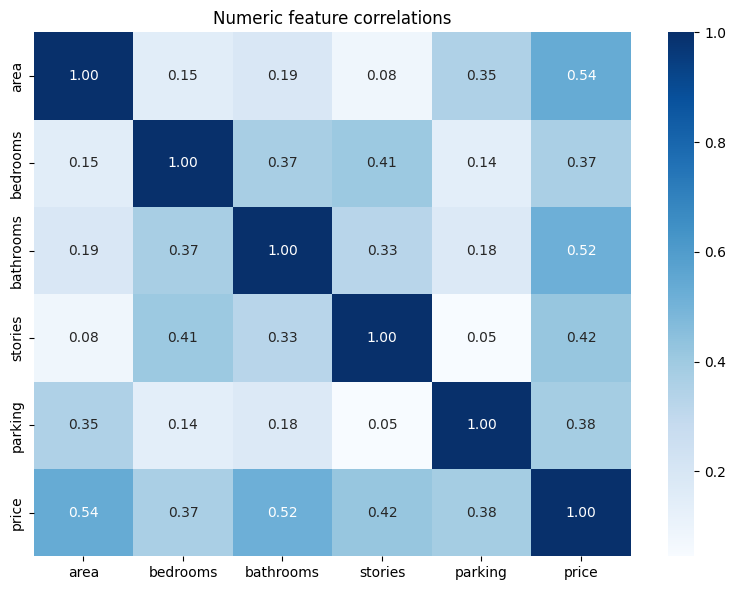

In [ ]:

plt.figure(figsize=(12,4)); sns.histplot(df["price"], kde=True, bins=30, color="steelblue"); plt.title("Price distribution"); plt.xlabel("Price"); plt.tight_layout(); plt.show()
plt.figure(figsize=(12,4)); sns.scatterplot(data=df, x="area", y="price", alpha=0.6); plt.title("Price vs Area"); plt.tight_layout(); plt.show()
corr = df[present_numeric + ["price"]].corr()
plt.figure(figsize=(8,6)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues"); plt.title("Numeric feature correlations"); plt.tight_layout(); plt.show()


Part 3 — Train/Test Split & Preprocessor

  Split the dataset into training and test sets. Build a ColumnTransformer that passes numeric and binary features and one‑hot encodes furnishingstatus for downstream models.


In [ ]:

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

all_numeric = present_numeric + binary_cols
categorical = ["furnishingstatus"]

preprocessor_all = ColumnTransformer(
    transformers=[
        ("num", "passthrough", all_numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical)
    ],
    remainder="drop"
)


Part 4 — Evaluation Helper

  Define a reusable function that fits a model, generates predictions, prints MAE/MSE/RMSE/R², and draws a residuals vs predictions plot for consistent evaluation across models.



In [ ]:

def evaluate_model(model, X_train, y_train, X_test, y_test, title):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(title)
    print(f"MAE: {mae:,.2f}")
    print(f"MSE: {mse:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R2: {r2:,.4f}")
    residuals = y_test - y_pred
    plt.figure(figsize=(8,4))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(0, color="red", ls="--")
    plt.title(f"Residuals vs Predictions — {title}")
    plt.xlabel("Predicted Price"); plt.ylabel("Residual")
    plt.tight_layout(); plt.show()
    return {"MAE":mae,"MSE":mse,"RMSE":rmse,"R2":r2,"y_pred":y_pred}


Part 5 — Simple Linear Regression (price ~ area)

Train a baseline model using only area to predict price, evaluate it on the test set, and visualize the fitted regression line over the data.

Simple Linear Regression (area)
MAE: 1,474,748.13
MSE: 3,675,286,604,768.19
RMSE: 1,917,103.70
R2: 0.2729


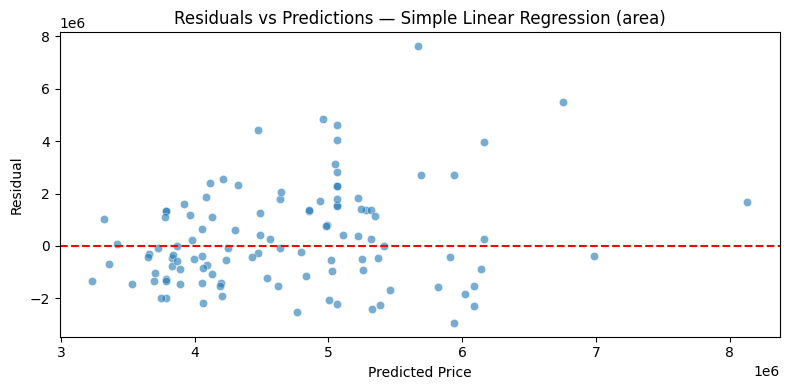

Text(0.5, 1.0, 'Price ~ Area')

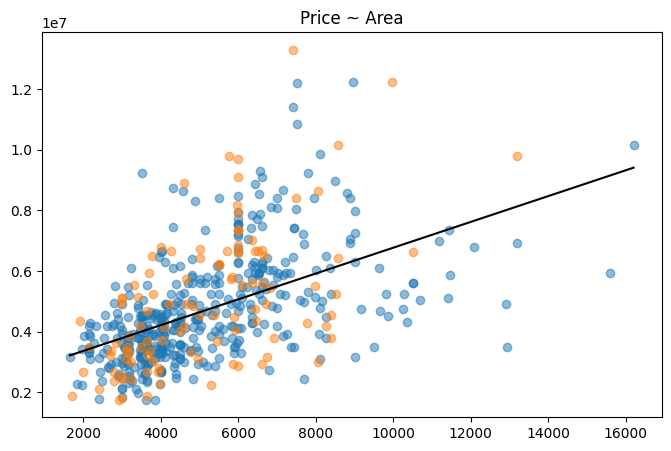

In [ ]:

X_train_area = X_train[["area"]].values
X_test_area = X_test[["area"]].values
lin_simple = LinearRegression()
res_simple = evaluate_model(lin_simple, X_train_area, y_train, X_test_area, y_test, "Simple Linear Regression (area)")
plt.figure(figsize=(8,5))
plt.scatter(X_train_area, y_train, alpha=0.5, label="Train")
plt.scatter(X_test_area, y_test, alpha=0.5, label="Test")
lin_simple.fit(X_train_area, y_train)
x_line = npx_line = np.linspace(X["area"].min(), X["area"].max(), 200).reshape(-1,1)
y_line = lin_simple.predict(x_line)
plt.plot(x_line, y_line, color="black", label="Fitted")
plt.title("Price ~ Area")


Part 6 — Multiple Linear Regression (all features)

   Train a linear regression model using all available features through the preprocessor and evaluate its performance on the test set.


Multiple Linear Regression (all features)
MAE: 970,043.40
MSE: 1,754,318,687,330.66
RMSE: 1,324,506.96
R2: 0.6529


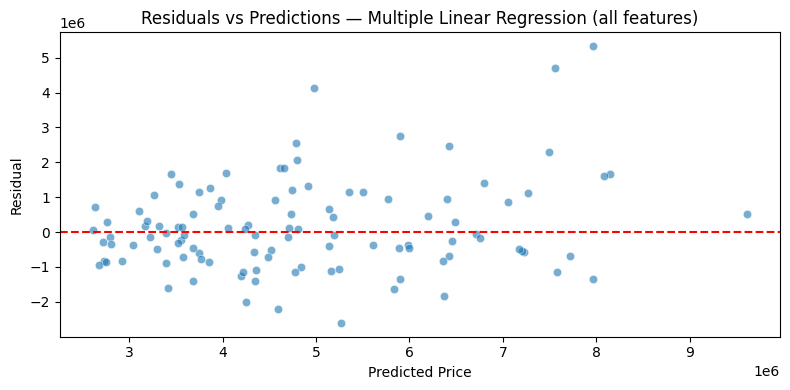

In [ ]:

mlr = Pipeline(steps=[("prep", preprocessor_all), ("reg", LinearRegression())])
res_mlr = evaluate_model(mlr, X_train, y_train, X_test, y_test, "Multiple Linear Regression (all features)")


Part 7 — Polynomial Regression (auto degree selection, area-only)

   Use GridSearchCV to select the best polynomial degree for area as the single predictor, train the best model, and evaluate on the test set.


Best polynomial degree: 5
Polynomial Regression (area, degree=5)
MAE: 1,465,969.36
MSE: 3,751,977,584,851.90
RMSE: 1,937,002.22
R2: 0.2577


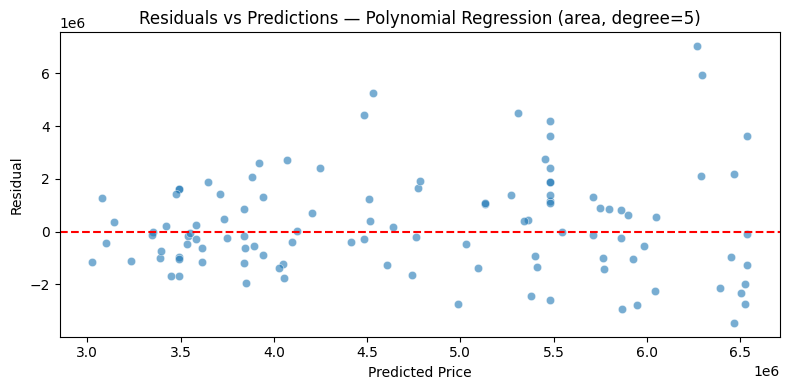

In [ ]:

poly_pipeline = Pipeline(steps=[("poly", PolynomialFeatures(include_bias=False)), ("reg", LinearRegression())])
param_grid_poly = {"poly__degree":[1,2,3,4,5]}
grid_poly = GridSearchCV(poly_pipeline, param_grid_poly, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid_poly.fit(X_train_area, y_train)
best_poly = grid_poly.best_estimator_
best_deg = grid_poly.best_params_["poly__degree"]
print(f"Best polynomial degree: {best_deg}")
res_poly = evaluate_model(best_poly, X_train_area, y_train, X_test_area, y_test, f"Polynomial Regression (area, degree={best_deg})")


Part 8 — KNN Regression (scaling + hyperparameter tuning)

    Build a pipeline with preprocessing and scaling, then use GridSearchCV to tune KNN hyperparameters (neighbors, weights, distance metric). Train the best KNN and evaluate.


Best KNN Params: {'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance'}
KNN Regression (tuned)
MAE: 1,026,914.44
MSE: 2,082,996,853,961.99
RMSE: 1,443,259.11
R2: 0.5879


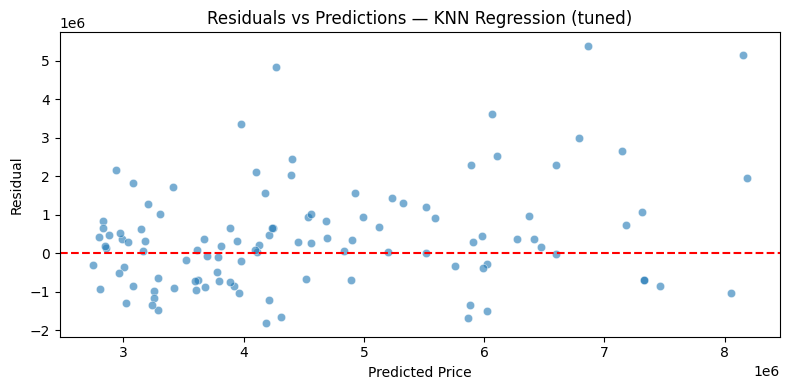

In [ ]:

knn_pipeline = Pipeline(steps=[("prep", preprocessor_all), ("scaler", StandardScaler(with_mean=False)), ("knn", KNeighborsRegressor())])
param_grid_knn = {"knn__n_neighbors":[3,5,7,9,11,15,21], "knn__weights":["uniform","distance"], "knn__p":[1,2]}
grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
print("Best KNN Params:", grid_knn.best_params_)
res_knn = evaluate_model(best_knn, X_train, y_train, X_test, y_test, "KNN Regression (tuned)")


Part 9 — Summary Table & R² Plot

  Collect metrics from all models, print a sorted summary table (by RMSE), and plot R² to compare model performance visually.


                         Model          MAE         RMSE       R2
Multiple Linear (all features) 9.700434e+05 1.324507e+06 0.652924
                   KNN (tuned) 1.026914e+06 1.443259e+06 0.587898
          Simple Linear (area) 1.474748e+06 1.917104e+06 0.272879
   Polynomial (area, degree=5) 1.465969e+06 1.937002e+06 0.257706


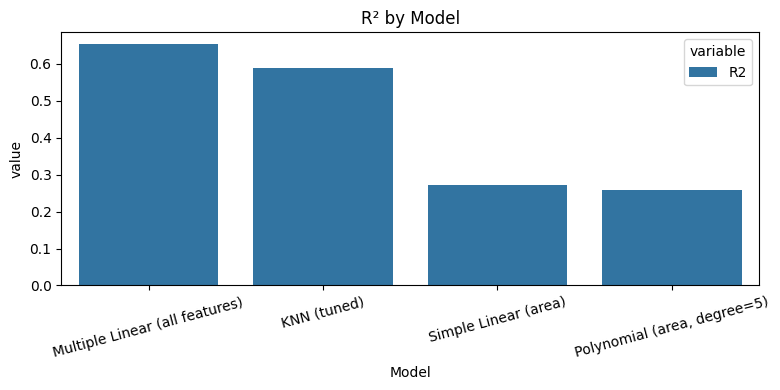

In [ ]:

summary = pd.DataFrame({
    "Model":[
        "Simple Linear (area)",
        f"Polynomial (area, degree={grid_poly.best_params_['poly__degree']})",
        "Multiple Linear (all features)",
        "KNN (tuned)"
    ],
    "MAE":[res_simple["MAE"], res_poly["MAE"], res_mlr["MAE"], res_knn["MAE"]],
    "RMSE":[res_simple["RMSE"], res_poly["RMSE"], res_mlr["RMSE"], res_knn["RMSE"]],
    "R2":[res_simple["R2"], res_poly["R2"], res_mlr["R2"], res_knn["R2"]]
}).sort_values(by="RMSE")
print(summary.to_string(index=False))
plt.figure(figsize=(8,4))
sns.barplot(data=summary.melt(id_vars="Model", value_vars=["R2"]), x="Model", y="value", hue="variable")
plt.title("R² by Model"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()


Part 10 — Predict Function For Unseen Samples

  Provide a function to predict price for new, unseen inputs (handling both string yes/no and numeric 0/1), then show example predictions using the tuned KNN model.


In [ ]:

def predict_unseen(example_dict, model=best_knn):
    row = pd.DataFrame([example_dict])
    for c in binary_cols:
        if c in row.columns:
            if row[c].dtype == object:
                row[c] = row[c].astype(str).str.strip().str.lower().map({"yes":1,"no":0})
            else:
                row[c] = row[c].astype(int)
    if "furnishingstatus" in row.columns:
        row["furnishingstatus"] = row["furnishingstatus"].astype(str).str.strip().str.lower()
    return float(model.predict(row)[0])

example = {
    "area": 6000,
    "bedrooms": 3,
    "bathrooms": 2,
    "stories": 2,
    "mainroad": "yes",
    "guestroom": "no",
    "basement": "no",
    "hotwaterheating": "no",
    "airconditioning": "yes",
    "parking": 2,
    "prefarea": "yes",
    "furnishingstatus": "semi-furnished"
}
pred_price = predict_unseen(example, model=best_knn)
print(f"Predicted price (best KNN, string inputs): {pred_price:,.0f}")

example_numeric = {
    "area": 6000,
    "bedrooms": 3,
    "bathrooms": 2,
    "stories": 2,
    "mainroad": 1,
    "guestroom": 0,
    "basement": 0,
    "hotwaterheating": 0,
    "airconditioning": 1,
    "parking": 2,
    "prefarea": 1,
    "furnishingstatus": "semi-furnished"
}
pred_price2 = predict_unseen(example_numeric, model=best_knn)
print(f"Predicted price (best KNN, numeric inputs): {pred_price2:,.0f}")


Predicted price (best KNN, string inputs): 7,378,065
Predicted price (best KNN, numeric inputs): 7,378,065
